# 3D Erythrocyte Reconstruction from Interferograms

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [13]:
import numpy as np
from cv_functions import *

In [19]:
img = cv2.imread(r"Images\Image 1b\Img-1.png", cv2.IMREAD_GRAYSCALE)

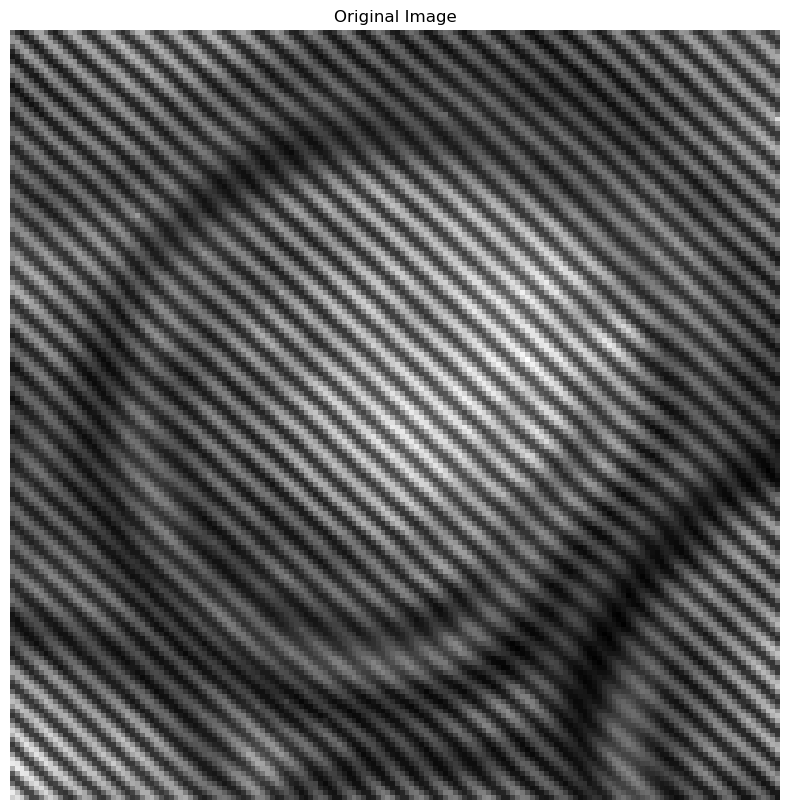

In [21]:
plt.figure(figsize=(10, 10))
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [1381]:
def remove_phase_tilt(phase, mask=None):
    h, w = phase.shape
    Y, X = np.mgrid[0:h, 0:w]
    if mask is None:
        mask = ~np.isnan(phase)
    Xf = X[mask].ravel()
    Yf = Y[mask].ravel()
    Zf = phase[mask].ravel()
    A = np.c_[Xf, Yf, np.ones_like(Xf)]
    C, _, _, _ = np.linalg.lstsq(A, Zf, rcond=None)
    plane = C[0]*X + C[1]*Y + C[2]
    return phase - plane

## 2D Fourier transform

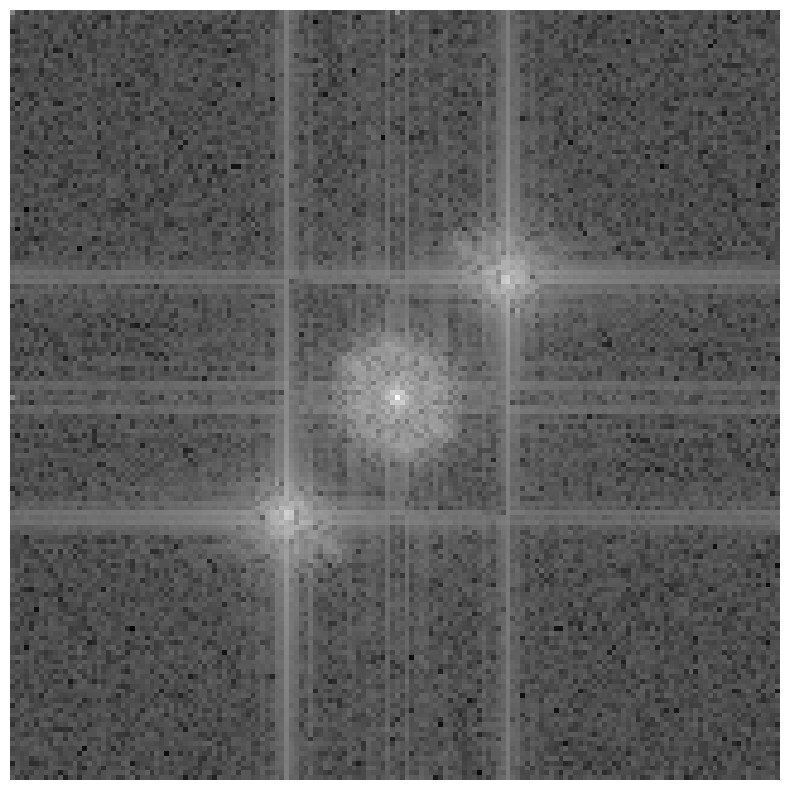

In [23]:
fft = np.fft.fftshift(np.fft.fft2(img))
spectrum = np.log(1 + np.abs(fft))
plt.figure(figsize=(10, 10))
plt.imshow(spectrum, cmap='gray')
plt.axis('off')
plt.show()

## Finding the first order

In [25]:
def mask_center(img, radius = 10, rotation90 = 0):
    h, w = np.rot90(img, rotation90).shape
    cy, cx = h//2, w//2
    Y, X = np.ogrid[:h, :w]
    mask = ((X-cx)**2 + (Y-cy)**2 <= radius**2) | ~((X >= cx) & (Y <= cy))
    mask = np.rot90(mask, rotation90)
    img_masked = img.copy()
    img_masked[mask] = 0
    return img_masked


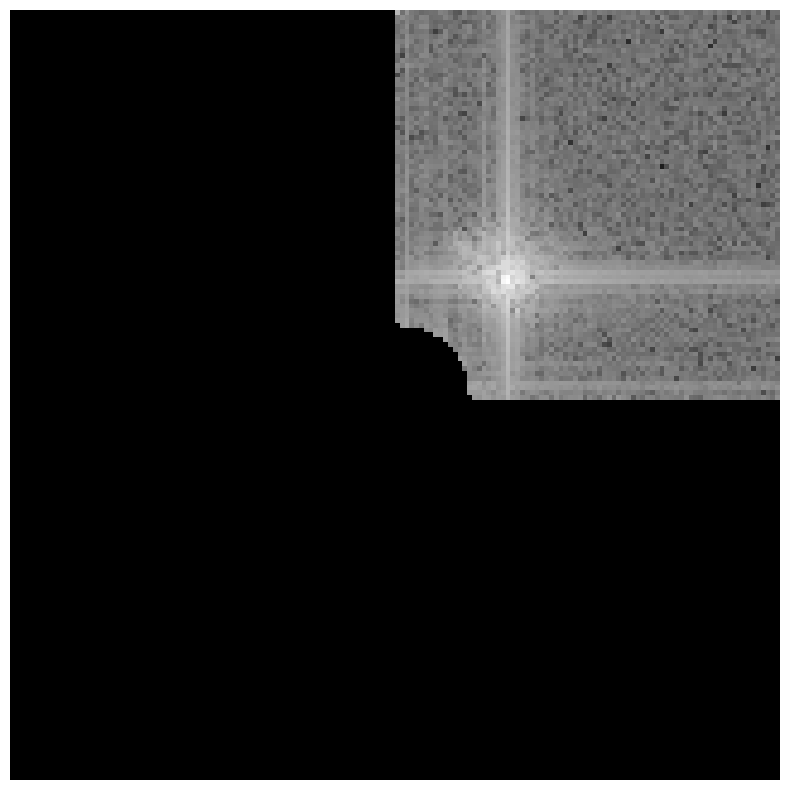

In [27]:
spectrum_masked = mask_center(spectrum, radius = 15)

plt.figure(figsize=(10, 10))
plt.imshow(spectrum_masked, cmap='gray')
plt.axis('off')
plt.show()

In [29]:
def find_plus_one_order_position(img, mask_radius=10, rotation90 = 0,  shift_x = 0, shift_y = 0):
    h, w = img.shape
    cy, cx = h//2, w//2
    spectrum_img = img.copy()
    spectrum_masked = mask_center(spectrum_img, rotation90=rotation90)
    f_y, f_x = np.unravel_index(np.argmax(spectrum_masked), spectrum_masked.shape)
    return f_x + shift_x, f_y + shift_y

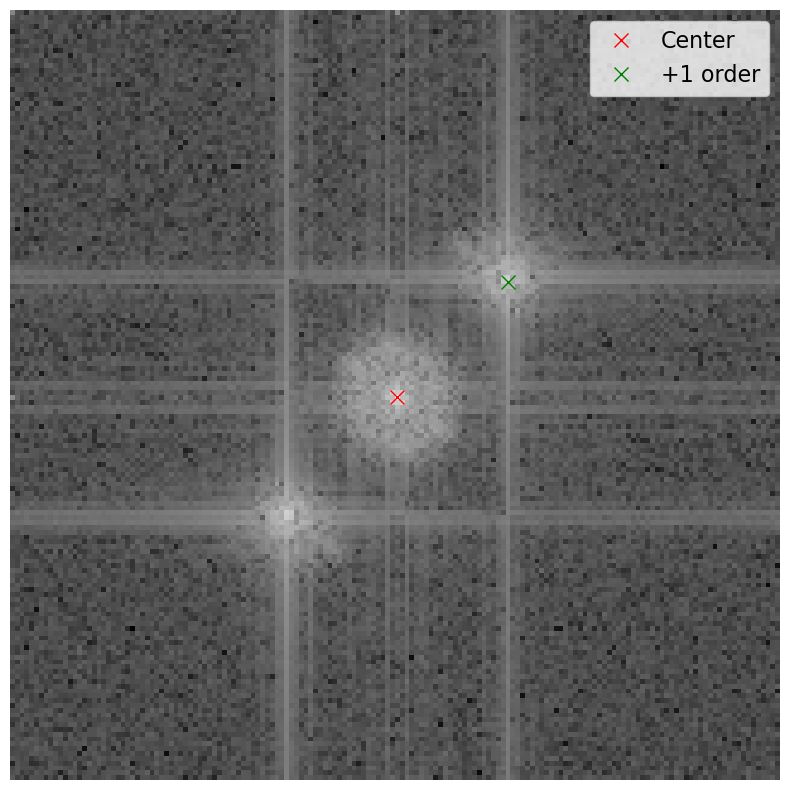

In [1406]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(spectrum, cmap='gray')
ax.plot(cx, cy, 'rx', markersize=10, label='Center')
ax.plot(f_x, f_y, 'gx', markersize=10, label='+1 order')

ax.legend()
ax.legend(fontsize=16)
ax.axis('off')

fig.savefig("spectrum_orders.png")

plt.show()

## Isolating the +1 order

In [36]:
def get_spectrum_image_from_fft(fft):
    return np.log(1 + np.abs(fft))

In [38]:
def filter_spectrum(fft, f_x, f_y, radius=100):
    h, w = fft.shape
    cy, cx = h//2, w//2

    filter_mask = np.zeros((h, w), dtype=bool)
    Y, X = np.ogrid[:h, :w]
    dist_sq = (Y - f_y)**2 + (X - f_x)**2
    filter_mask = dist_sq < radius**2
    fft_filtered = np.zeros_like(fft)
    fft_filtered[filter_mask] = fft[filter_mask]
    return fft_filtered

In [40]:
def soft_circle_filter(fft, f_x, f_y, radius=50):
    h, w = fft.shape

    Y, X = np.ogrid[:h, :w]
    r = np.sqrt((X - f_x)**2 + (Y - f_y)**2)

    mask = np.zeros_like(r)

    mask[r <= radius] = 1
    edge = (r > radius) & (r < radius * 1.5)

    mask[edge] = 0.5 * (1 + np.cos(np.pi * (r[edge] - radius) / (radius * 0.5)))

    return fft * mask

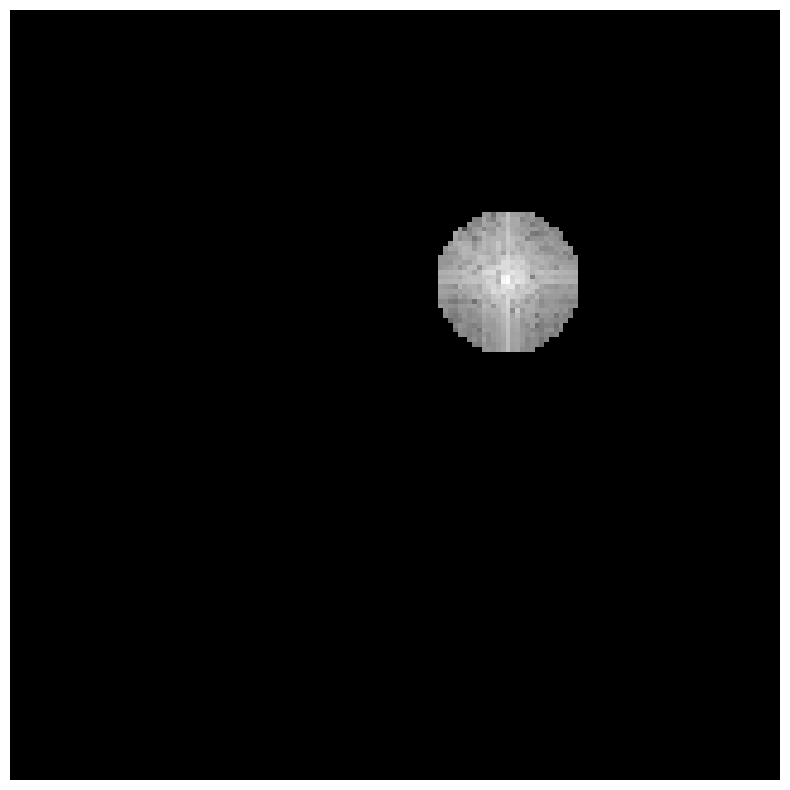

In [42]:
filtered_spectrum = filter_spectrum(fft, f_x, f_y, radius=15)

plt.figure(figsize=(10, 10))
plt.imshow(get_spectrum_image_from_fft(filtered_spectrum), cmap='gray')
plt.axis('off')
plt.show()

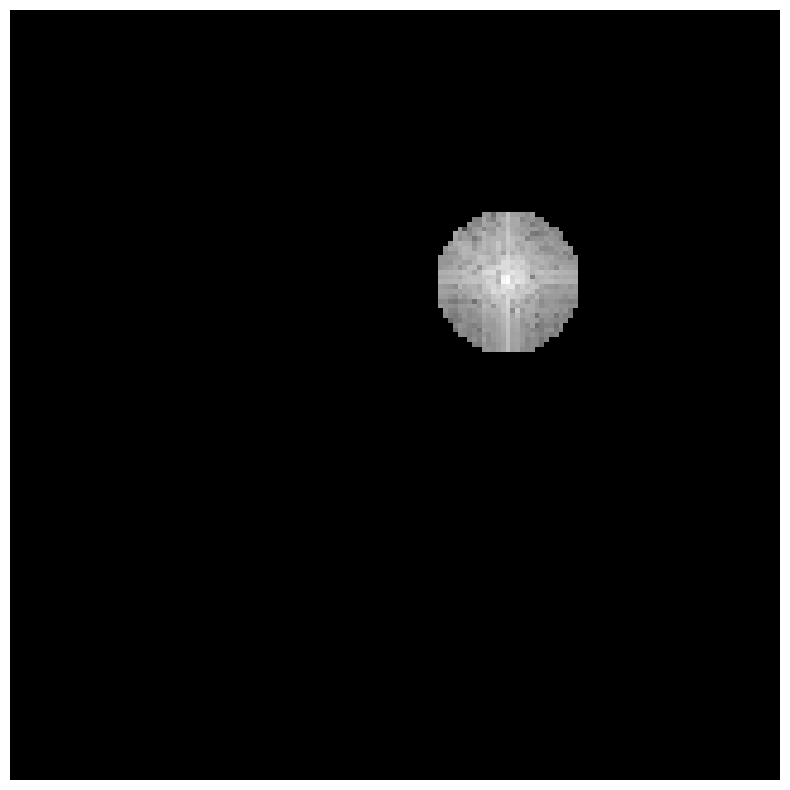

In [44]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(get_spectrum_image_from_fft(filtered_spectrum), cmap='gray')
ax.axis('off')
fig.savefig(
    "filtered_spectrum.png",
    bbox_inches='tight',
    pad_inches=0
)

plt.show()

## Moving the first order to the image center

In [70]:
def center_spectrum(fft, f_x, f_y, shift_x = 0, shift_y = 0):
    h, w = fft.shape
    c_y, c_x = h//2, w//2
    spectrum_centred = np.roll(fft, -int(f_y - c_y), axis=0)
    spectrum_centred = np.roll(spectrum_centred, -int(f_x - c_x), axis=1)
    return spectrum_centred
    

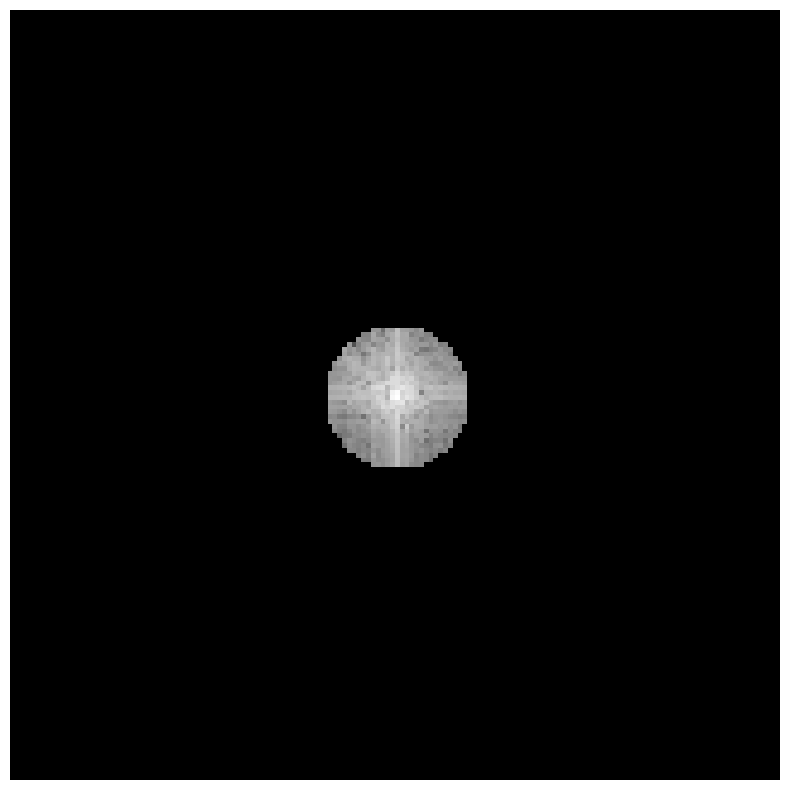

In [72]:


centered_spectrum = center_spectrum(filtered_spectrum, f_x, f_y)

plt.figure(figsize=(10, 10))
plt.imshow(get_spectrum_image_from_fft(centered_spectrum) , cmap='gray')
plt.axis('off')
plt.show()

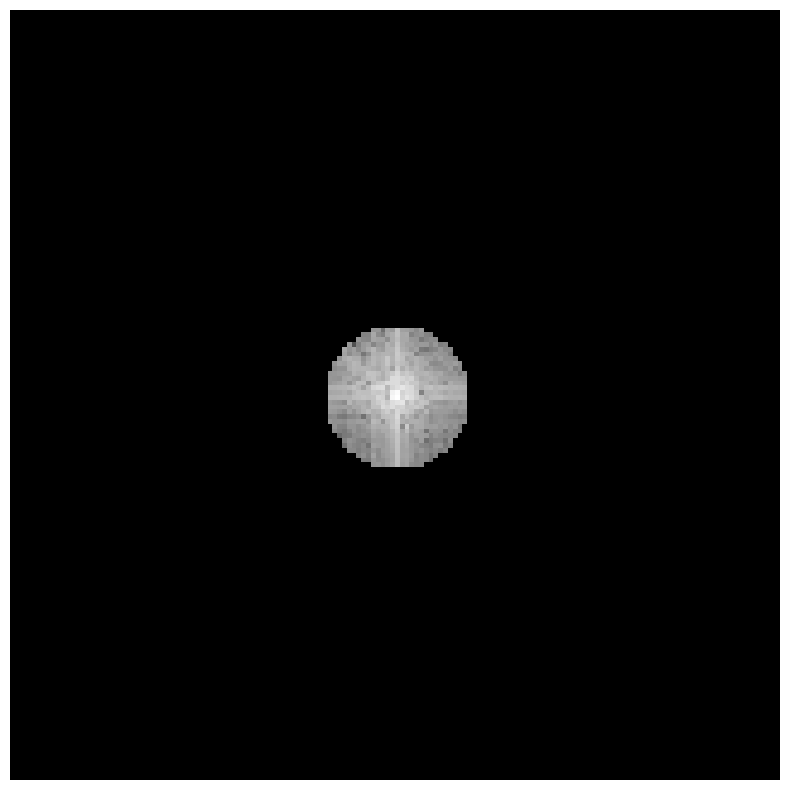

In [74]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(get_spectrum_image_from_fft(centered_spectrum), cmap='gray')
ax.axis('off')
fig.savefig(
    "centered_spectrum.png",
    bbox_inches='tight',
    pad_inches=0
)

plt.show()

## Reverse Fourier Transform

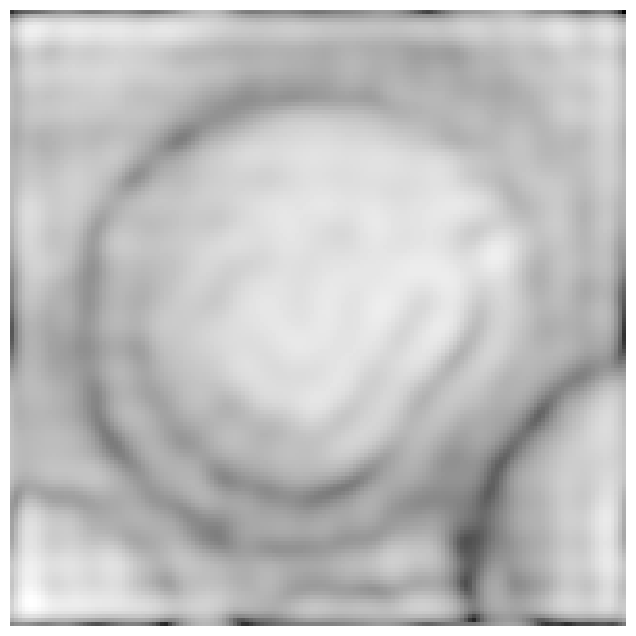

In [77]:
complex_field = np.fft.ifft2(np.fft.ifftshift(centered_spectrum))

plt.figure(figsize=(8, 8))
plt.imshow(get_spectrum_image_from_fft(complex_field), cmap='gray')
plt.axis('off')
plt.show()

## Calculating the phase as a complex part of the signal

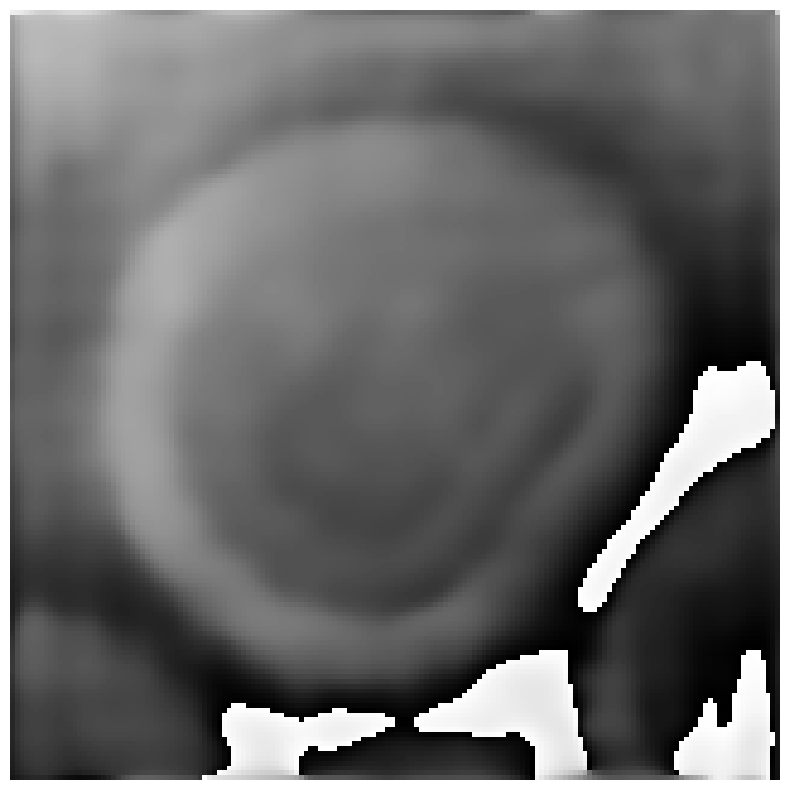

In [80]:
from skimage.restoration import unwrap_phase

phase_wrapped = np.angle(complex_field)

plt.figure(figsize=(10, 10))
plt.imshow(phase_wrapped, cmap='gray')
plt.axis('off')
plt.show()

In [82]:
from skimage.restoration import unwrap_phase
phase_unwrapped = unwrap_phase(phase_wrapped)

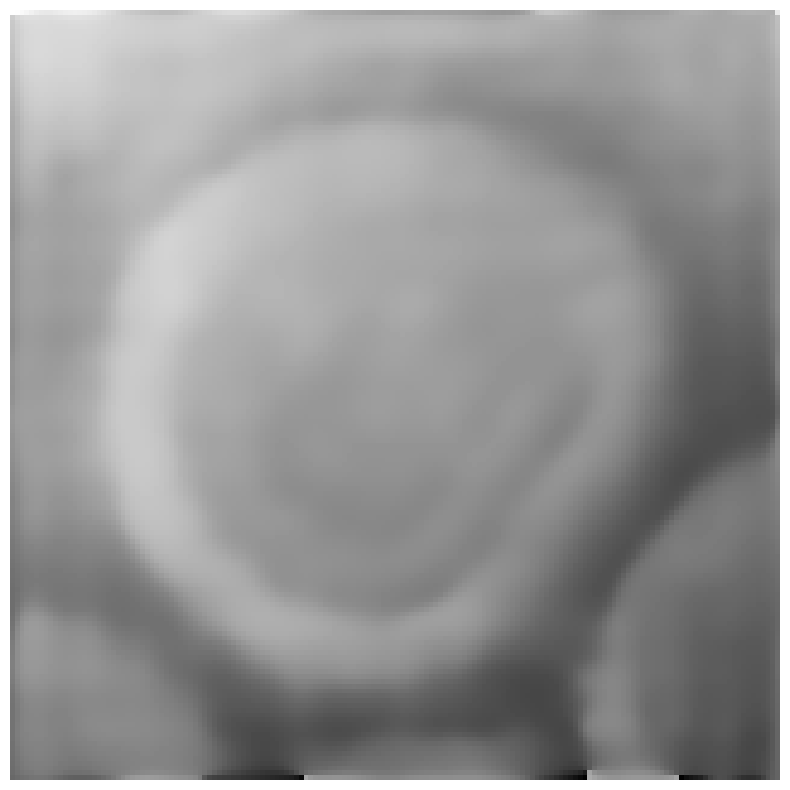

In [84]:
plt.figure(figsize=(10, 10))
plt.imshow(phase_unwrapped, cmap='gray')
plt.axis('off')
plt.show()

In [86]:
def remove_phase_tilt(phase, mask=None):
    h, w = phase.shape
    Y, X = np.mgrid[0:h, 0:w]

    if mask is None:
        mask = ~np.isnan(phase)

    Xf = X[mask].ravel()
    Yf = Y[mask].ravel()
    Zf = phase[mask].ravel()

    A = np.c_[Xf, Yf, np.ones_like(Xf)]
    C, _, _, _ = np.linalg.lstsq(A, Zf, rcond=None)

    plane = C[0]*X + C[1]*Y + C[2]
    return phase - plane

In [88]:
phase = remove_phase_tilt(phase_unwrapped, mask=None)

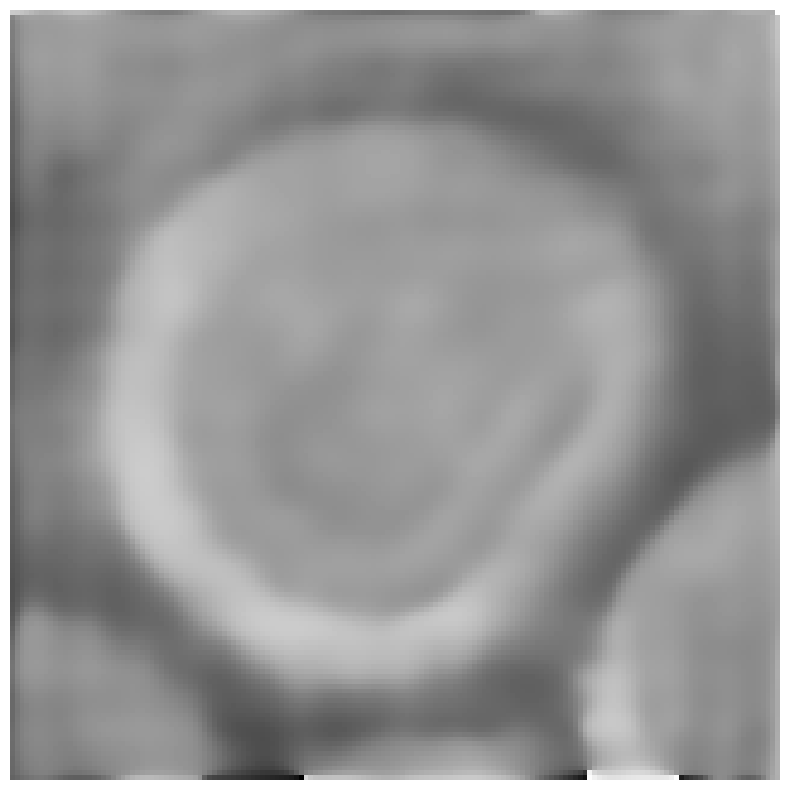

In [90]:
plt.figure(figsize=(10, 10))
plt.imshow(phase, cmap='gray')
plt.axis('off')
plt.show()

## Creating a 3D plot

In [92]:
def get_3d_phase(phase, pixel_size=2.2, wavelength=0.65, zoom=80, delta_n=0.4):
    h, w = phase.shape

    step = 1
    x = np.arange(0, w, step)
    y = np.arange(0, h, step)
    X_3d, Y_3d = np.meshgrid(x, y)
    Z_3d = phase[::step, ::step]

    X_microns = X_3d * pixel_size / zoom
    Y_microns = Y_3d * pixel_size / zoom
    Z_microns = Z_3d * wavelength / (2 * np.pi * delta_n)   # высота с учётом delta_n

    return X_microns, Y_microns, Z_microns

In [94]:
def plot_3D_phase(phase, pixel_size = 2.2, wavelength = 0.65, zoom = 80,  delta_n=0.40, standalone=True):


    X_microns, Y_microns, Z_microns = get_3d_phase(phase, pixel_size=pixel_size, wavelength=wavelength, zoom=zoom)

    
    fig = None
    ax = None
    if(standalone):
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')
    else:
        fig = plt.gcf()
        ax = plt.gca()
        
    
    z_min = Z_microns.min()
    z_max = Z_microns.max()
    
    surf = ax.plot_surface(X_microns, Y_microns, Z_microns,
                          cmap='turbo',
                          alpha=0.9,
                          linewidth=0.1,
                          antialiased=True,
                          vmin=z_min,
                          vmax=z_max)
    
    fig.colorbar(surf, shrink=0.5, aspect=10, label='Height (μm)')
    ax.view_init(elev=30, azim=45)
    ax.set_box_aspect([1, 1, 1])
    
    ax.set_xlabel('X (μm)')
    ax.set_ylabel('Y (μm)')

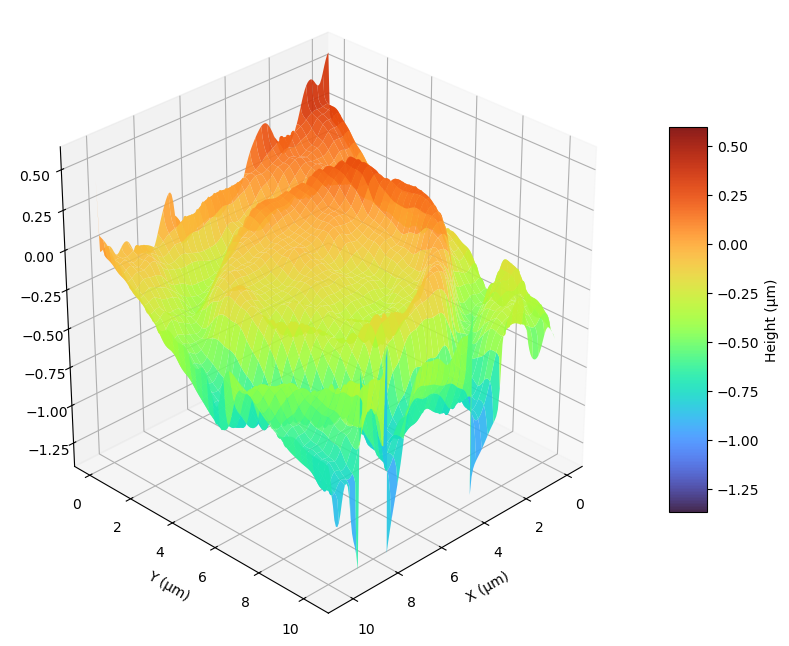

In [96]:
plot_3D_phase(phase_unwrapped, pixel_size = 5.2, wavelength = 0.55,  zoom = 80)

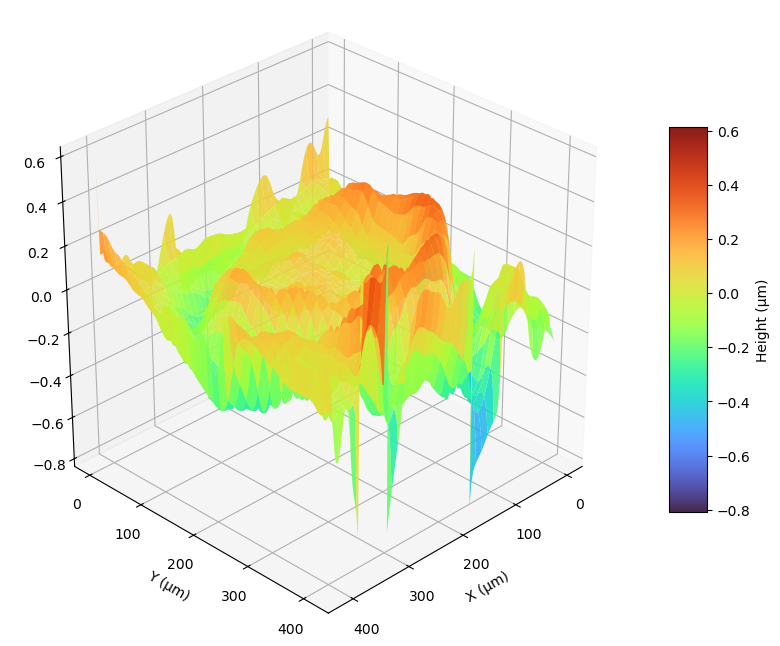

In [98]:
plot_3D_phase(phase, pixel_size = 5.2, wavelength = 0.55,  zoom = 2)

## Full function for creating a 3D plot of an erythrocyte

In [100]:
def plot_3D_phase_from_image(img, pixel_size = 2.2, wavelength = 0.65, zoom = 80, mask_radius = 15, filter_radius = 15, standalone=True):
    fft = np.fft.fftshift(np.fft.fft2(img))
    spectrum = np.log(1 + np.abs(fft))
    f_x, f_y = find_plus_one_order_position(spectrum, mask_radius = mask_radius)
    filtered_spectrum = filter_spectrum(fft, f_x, f_y, radius=filter_radius)
    centered_spectrum = center_spectrum(filtered_spectrum, f_x, f_y)
    amplitude = np.fft.ifft2(np.fft.ifftshift(centered_spectrum))
    phase_wrapped = np.angle(amplitude)
    phase_unwrapped = unwrap_phase(phase_wrapped)
    plot_3D_phase(phase_unwrapped, pixel_size = pixel_size, wavelength = wavelength, zoom = zoom, standalone=standalone)

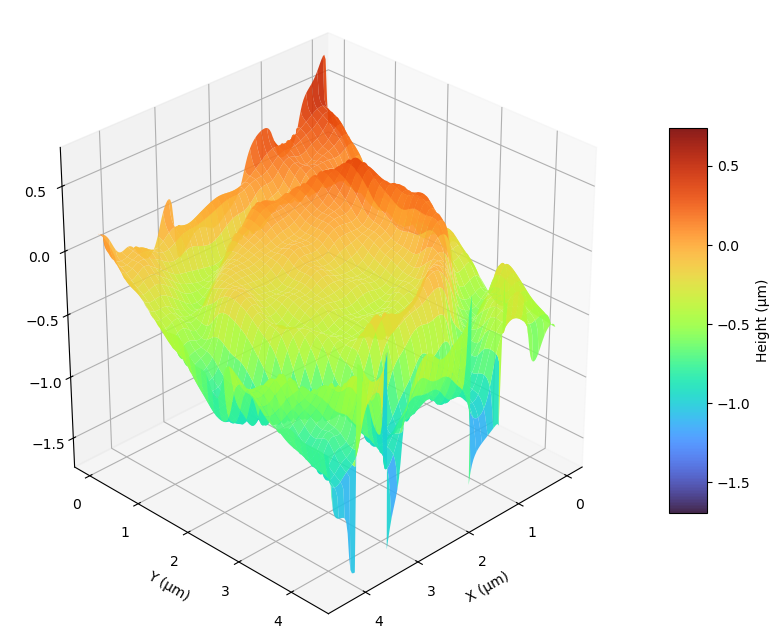

In [102]:
plot_3D_phase_from_image(img, filter_radius = 10)

## Creating a 3D model

In [1476]:
def get_3d_phase(phase, pixel_size=2.2, wavelength=0.65, zoom=80, delta_n=0.40):
    h, w = phase.shape

    step = 1
    x = np.arange(0, w, step)
    y = np.arange(0, h, step)
    X_3d, Y_3d = np.meshgrid(x, y)
    Z_3d = phase[::step, ::step]

    X_microns = X_3d * pixel_size / zoom
    Y_microns = Y_3d * pixel_size / zoom
    Z_microns = Z_3d * wavelength / (2 * np.pi * delta_n)   # высота с учётом delta_n

    return X_microns, Y_microns, Z_microns

In [1478]:
def create_erythrocyte_3D_model_from_phase(phase, pixel_size=2.2, wavelength=0.65, zoom=240,
                                           delta_n=0.40, smooth_sigma=1,
                                           visual_scale=1, height_scale=1.0,
                                           filename='3D Models/erythrocyte_surface.stl'):

    X, Y, Z = get_3d_phase(phase, pixel_size, wavelength, zoom, delta_n)
    Z_smoothed = gaussian_filter(Z, sigma=smooth_sigma)

    def create_mesh_from_surface(X, Y, Z, filename):
        h, w = Z.shape
        vertices = []
        faces = []
        for i in range(h):
            for j in range(w):
                vertices.append([X[i, j] * visual_scale,
                                 Y[i, j] * visual_scale,
                                 Z[i, j] * visual_scale * height_scale])
        for i in range(h - 1):
            for j in range(w - 1):
                p1 = i * w + j
                p2 = i * w + (j + 1)
                p3 = (i + 1) * w + j
                p4 = (i + 1) * w + (j + 1)
                faces.append([p1, p2, p3])
                faces.append([p2, p4, p3])
        mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
        mesh.export(filename)
        print(f"Model saved: {filename}")
        return mesh

    mesh = create_mesh_from_surface(X, Y, Z_smoothed, filename)
    return mesh

In [1480]:
create_erythrocyte_3D_model_from_phase(phase, pixel_size=5.2, wavelength=0.55)

Model saved: 3D Models/erythrocyte_surface.stl


<trimesh.Trimesh(vertices.shape=(25600, 3), faces.shape=(50562, 3))>

In [931]:
create_erythrocyte_3D_model_from_phase(phase_unwrapped)

Центр: 1.442 мкм
Край: 2.400 мкм
Model saved: 3D Models/erythrocyte_real.stl
Model saved: 3D Models/erythrocyte_normal_reference.stl


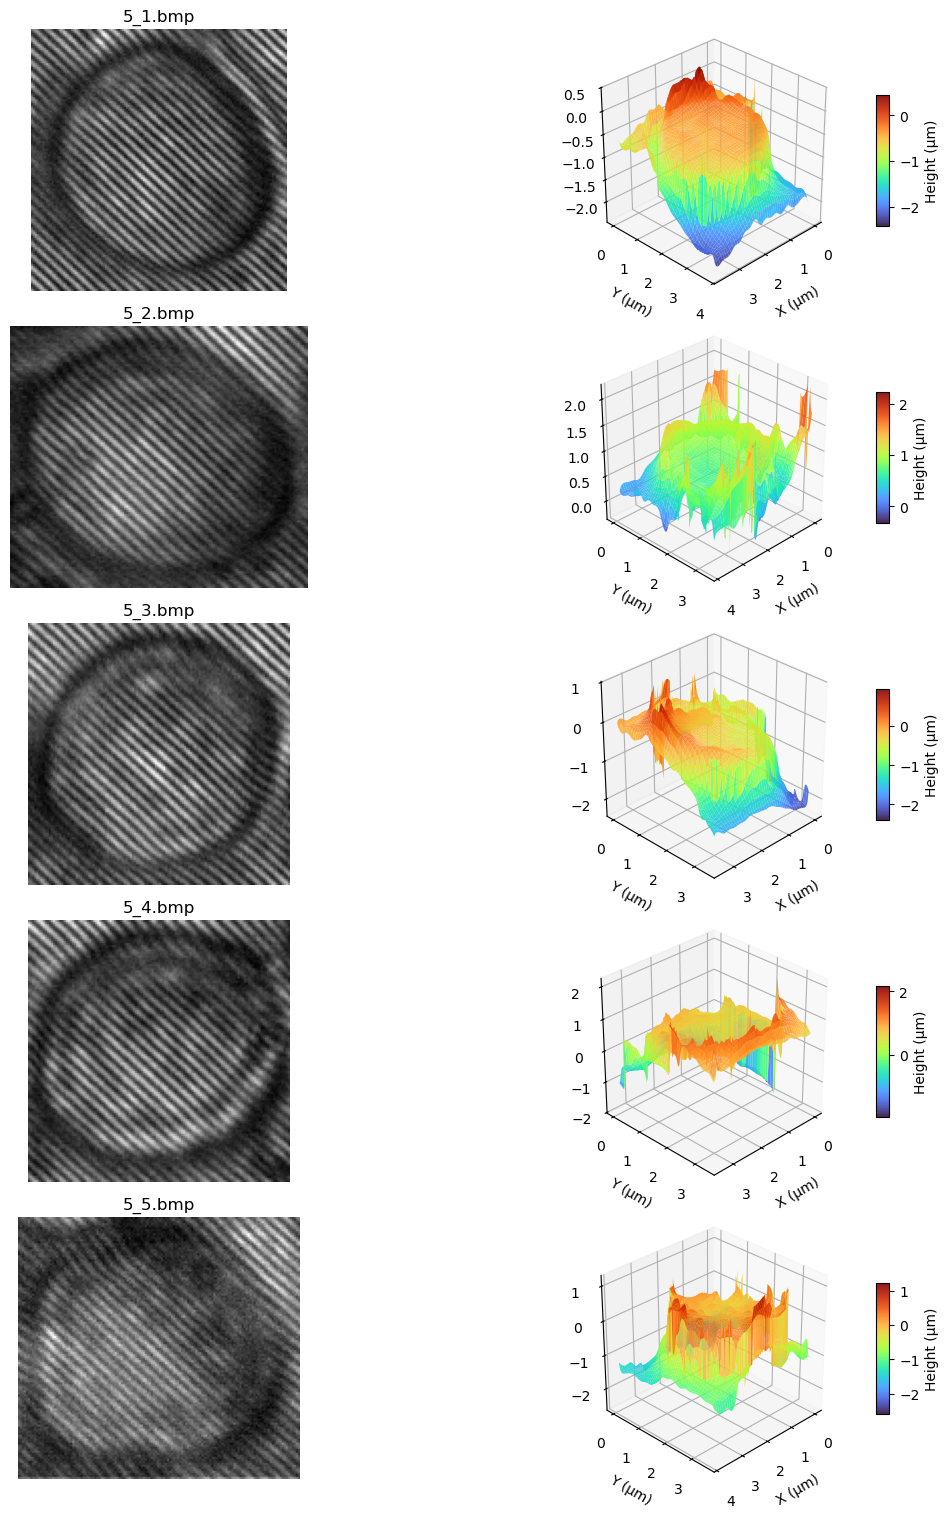

In [110]:
import os
import cv2
import matplotlib.pyplot as plt

files = os.listdir("Images/Image 5/single_cells_5/")
files.sort()


n_show = 5
files = files[:n_show]

fig = plt.figure(figsize=(12, 3*n_show))

for idx, filename in enumerate(files):
    image = cv2.imread("Images/Image 5/single_cells_5/" + filename, cv2.IMREAD_GRAYSCALE)

    ax1 = plt.subplot(n_show, 2, idx*2 + 1)
    ax1.imshow(image, cmap='gray')
    ax1.set_title(filename)
    ax1.axis('off')

    ax2 = plt.subplot(n_show, 2, idx*2 + 2, projection='3d')

    plot_3D_phase_from_image(image, filter_radius = 10, standalone=False)

plt.tight_layout()
plt.show()